In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("games_final.csv")
df_1=pd.read_csv("vgsales_cleaned.csv")

Top rated games by user reviews

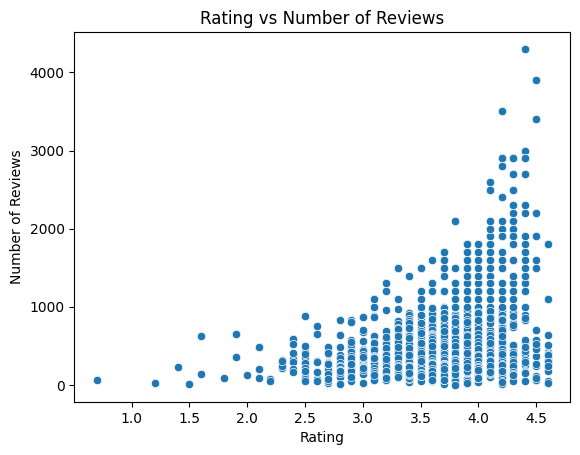

In [ ]:
df = pd.read_csv("games_final.csv")
sns.scatterplot(
    x="Rating",
    y="Number of Reviews",
    data=df
)
plt.title("Rating vs Number of Reviews")
plt.show()


In [ ]:
df.columns

Index(['Title', 'Release Date', 'Team', 'Rating', 'Times Listed',
       'Number of Reviews', 'Genres', 'Plays', 'Playing', 'Backlogs',
       'Wishlist'],
      dtype='object')

Developers (Teams) have the highest average ratings

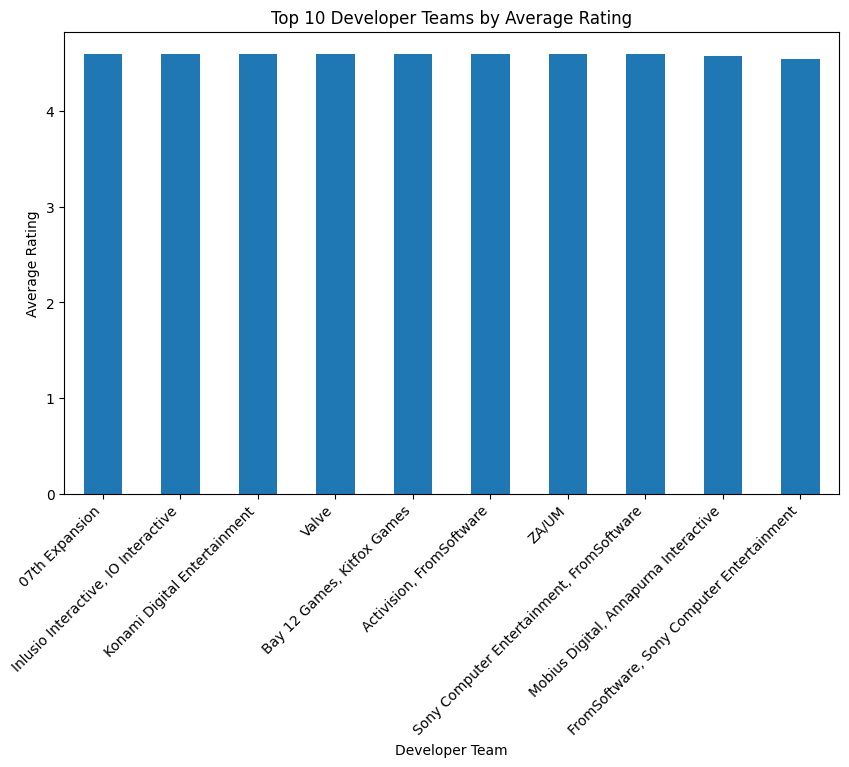

In [16]:

team_rating_df = df[["Team", "Rating"]].copy()
team_avg_rating = (
    team_rating_df
    .groupby("Team")["Rating"]
    .mean()
    .sort_values(ascending=False)
)
top_teams = team_avg_rating.head(10)
plt.figure(figsize=(10,6))
top_teams.plot(kind="bar")

plt.xlabel("Developer Team")
plt.ylabel("Average Rating")
plt.title("Top 10 Developer Teams by Average Rating")
plt.xticks(rotation=45, ha="right")
plt.show()


The most common genres in the dataset

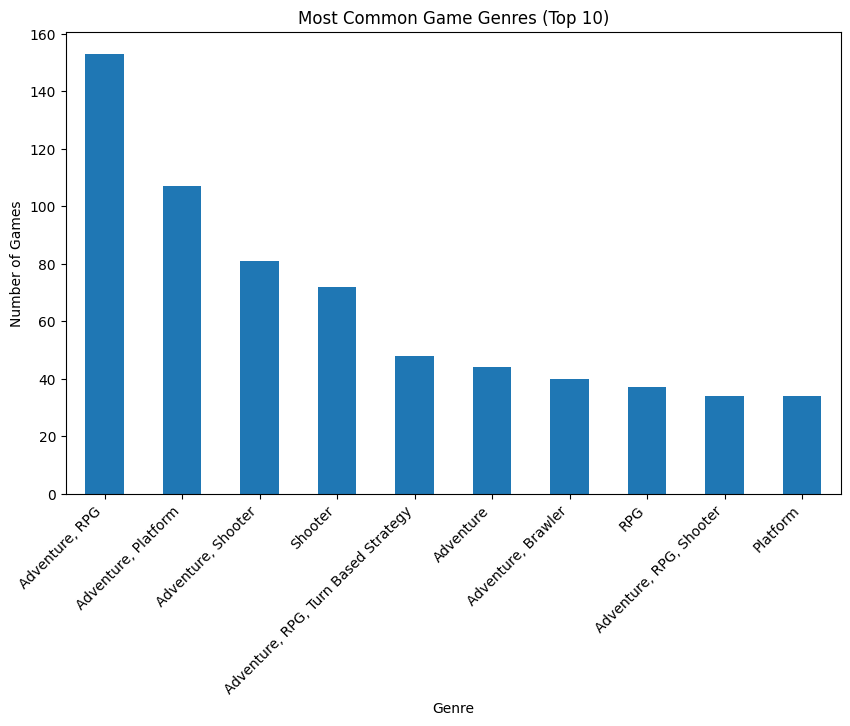

In [17]:

genre_df = df[["Genres"]].copy()
genre_counts = (
    genre_df["Genres"]
    .value_counts()
    .head(10)
)
plt.figure(figsize=(10,6))
genre_counts.plot(kind="bar")

plt.xlabel("Genre")
plt.ylabel("Number of Games")
plt.title("Most Common Game Genres (Top 10)")
plt.xticks(rotation=45, ha="right")
plt.show()


Which games have the highest backlog compared to wishlist


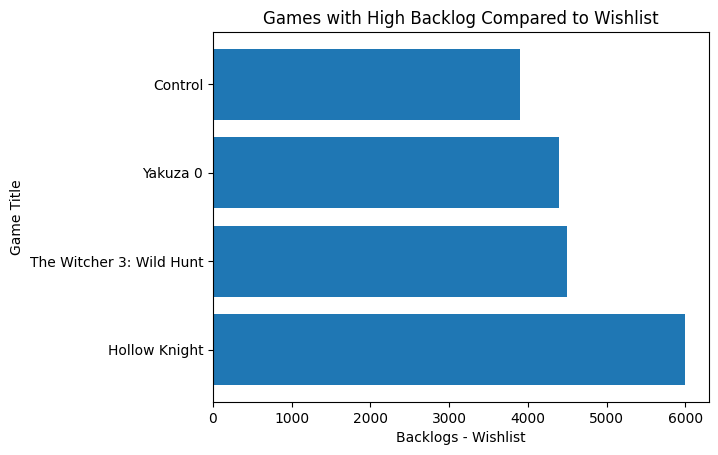

In [ ]:
df["Backlog_Diff"] = df["Backlogs"] - df["Wishlist"]
top_backlog = df.sort_values("Backlog_Diff", ascending=False).head(10)

plt.figure()
plt.barh(top_backlog["Title"], top_backlog["Backlog_Diff"])
plt.xlabel("Backlogs - Wishlist")
plt.ylabel("Game Title")
plt.title("Games with High Backlog Compared to Wishlist")
plt.show()



The game release trend across years

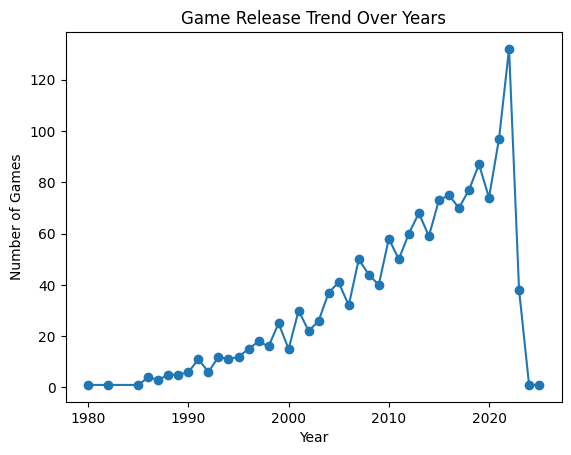

In [ ]:
df["Year"] = pd.to_datetime(df["Release Date"]).dt.year

year_count = df["Year"].value_counts().sort_index()

plt.figure()
plt.plot(year_count.index, year_count.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Number of Games")
plt.title("Game Release Trend Over Years")
plt.show()


The distribution of user ratings

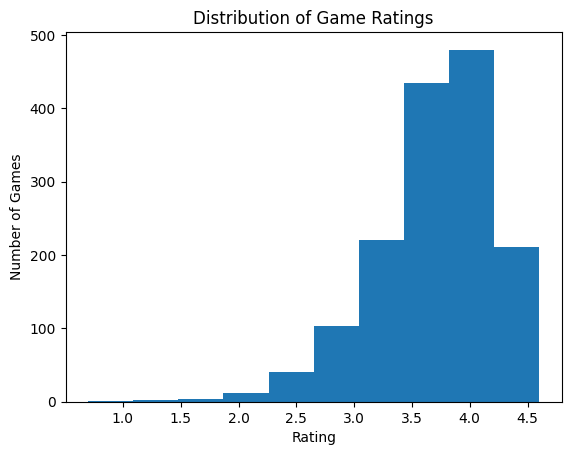

In [ ]:
plt.figure()
plt.hist(df["Rating"], bins=10)
plt.xlabel("Rating")
plt.ylabel("Number of Games")
plt.title("Distribution of Game Ratings")
plt.show()


The top 10 most wishlisted games

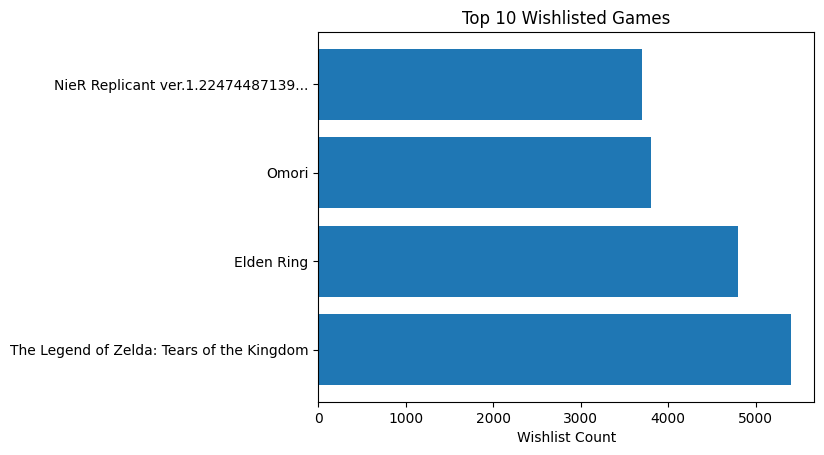

In [ ]:
top_wishlist = df.sort_values("Wishlist", ascending=False).head(10)

plt.figure()
plt.barh(top_wishlist["Title"], top_wishlist["Wishlist"])
plt.xlabel("Wishlist Count")
plt.title("Top 10 Wishlisted Games")
plt.show()


The average number of plays per genre

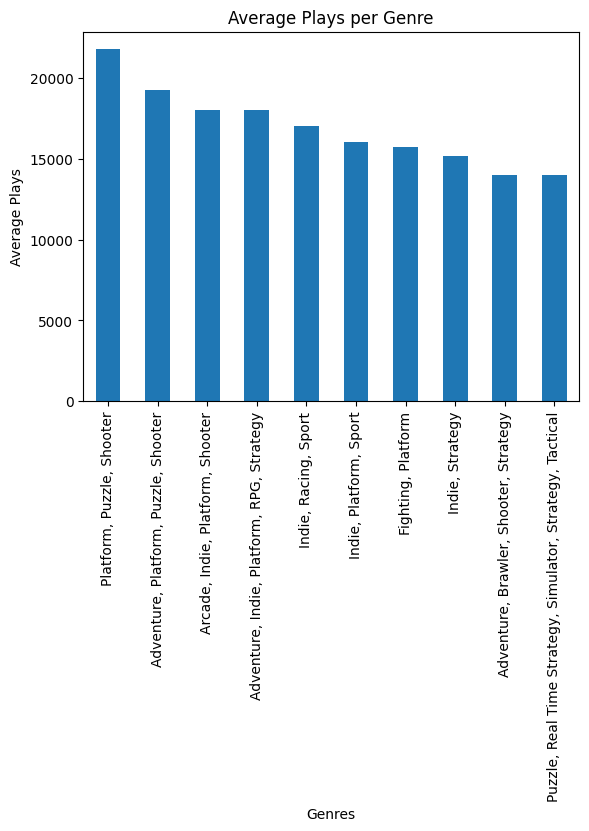

In [ ]:
avg_plays = df.groupby("Genres")["Plays"].mean().sort_values(ascending=False).head(10)

plt.figure()
avg_plays.plot(kind="bar")
plt.ylabel("Average Plays")
plt.title("Average Plays per Genre")
plt.show()


Developer studios are the most productive and impactful

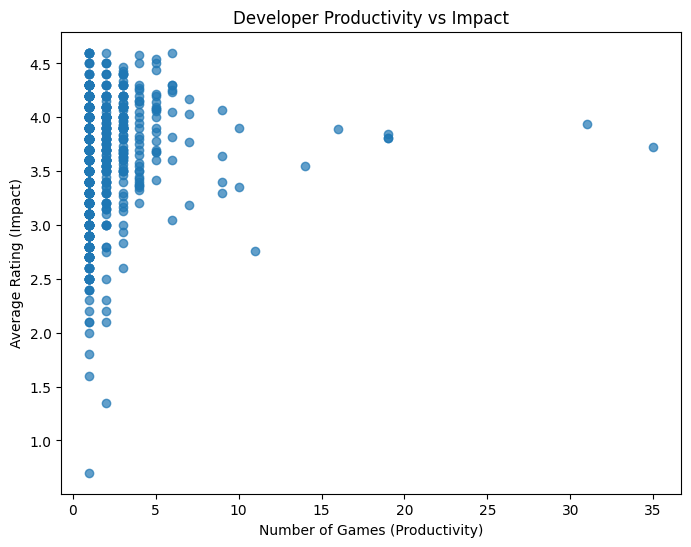

In [18]:

studio_df = df[["Team", "Title", "Rating"]].copy()
productivity = (
    studio_df
    .groupby("Team")["Title"]
    .count()
)
impact = (
    studio_df
    .groupby("Team")["Rating"]
    .mean()
)
studio_summary = pd.concat([productivity, impact], axis=1)
studio_summary.columns = ["Game_Count", "Avg_Rating"]
plt.figure(figsize=(8,6))
plt.scatter(
    studio_summary["Game_Count"],
    studio_summary["Avg_Rating"],
    alpha=0.7
)

plt.xlabel("Number of Games (Productivity)")
plt.ylabel("Average Rating (Impact)")
plt.title("Developer Productivity vs Impact")
plt.show()


Which region generates the most game sales


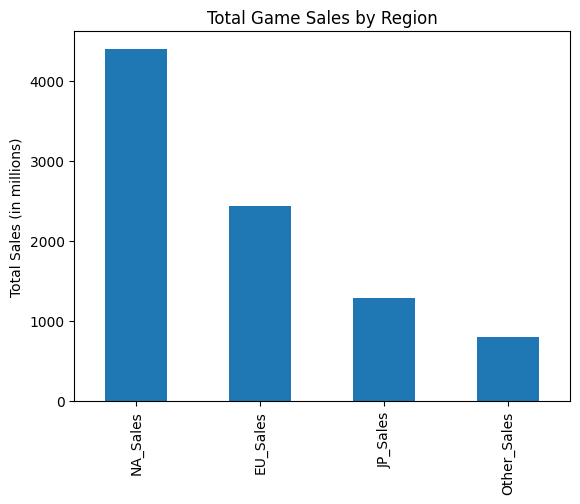

In [ ]:
region_sales = df_1[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum()

plt.figure()
region_sales.plot(kind="bar")
plt.ylabel("Total Sales (in millions)")
plt.title("Total Game Sales by Region")
plt.show()


What are the best-selling platforms

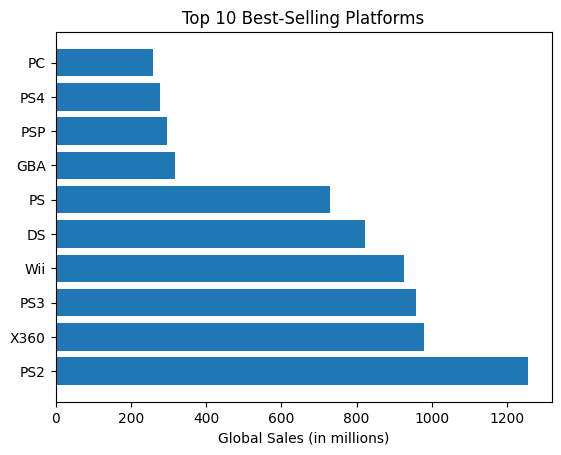

In [ ]:
platform_sales = df_1.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).head(10)

plt.figure()
plt.barh(platform_sales.index, platform_sales.values)
plt.xlabel("Global Sales (in millions)")
plt.title("Top 10 Best-Selling Platforms")
plt.show()


Trend of game releases and sales over years




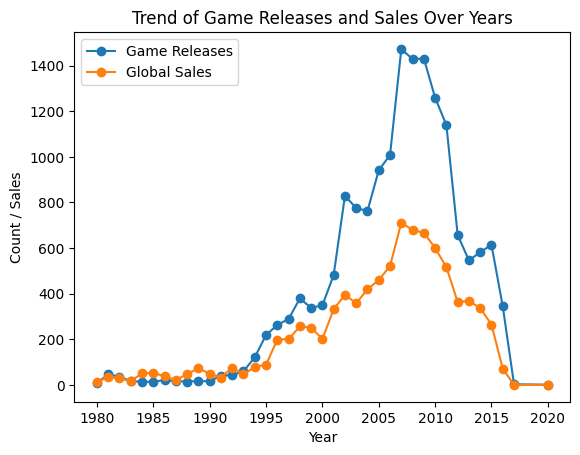

In [ ]:

release_trend = df_1["Year"].value_counts().sort_index()
sales_trend = df_1.groupby("Year")["Global_Sales"].sum()

plt.figure()
plt.plot(release_trend.index, release_trend.values, label="Game Releases", marker='o')
plt.plot(sales_trend.index, sales_trend.values, label="Global Sales", marker='o')

plt.xlabel("Year")
plt.ylabel("Count / Sales")
plt.title("Trend of Game Releases and Sales Over Years")
plt.legend()
plt.show()


 The top publishers by sales

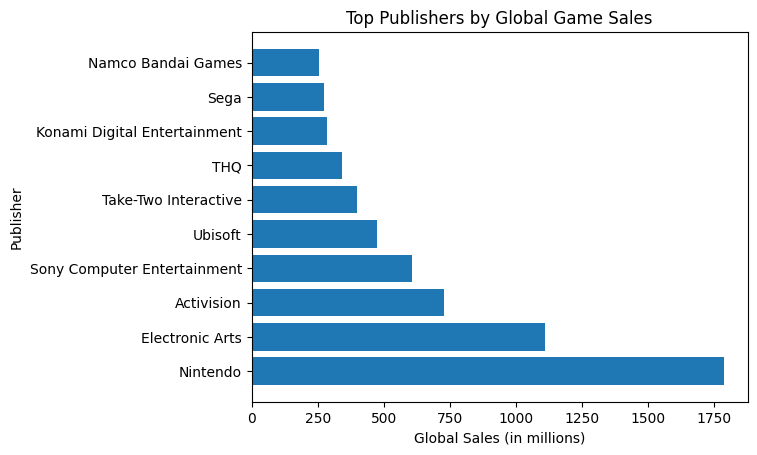

In [ ]:
publisher_sales = (
    df_1.groupby("Publisher")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
plt.barh(publisher_sales.index, publisher_sales.values)
plt.xlabel("Global Sales (in millions)")
plt.ylabel("Publisher")
plt.title("Top Publishers by Global Game Sales")
plt.show()


Which games are the top 10 best-sellers globally

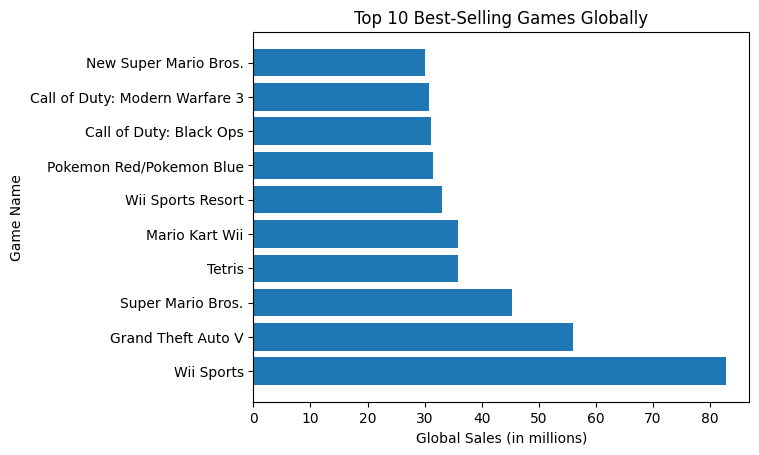

In [ ]:
top_games = (
    df_1.groupby("Name")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
plt.barh(top_games.index, top_games.values)
plt.xlabel("Global Sales (in millions)")
plt.ylabel("Game Name")
plt.title("Top 10 Best-Selling Games Globally")
plt.show()


Regional sales compare for specific platforms

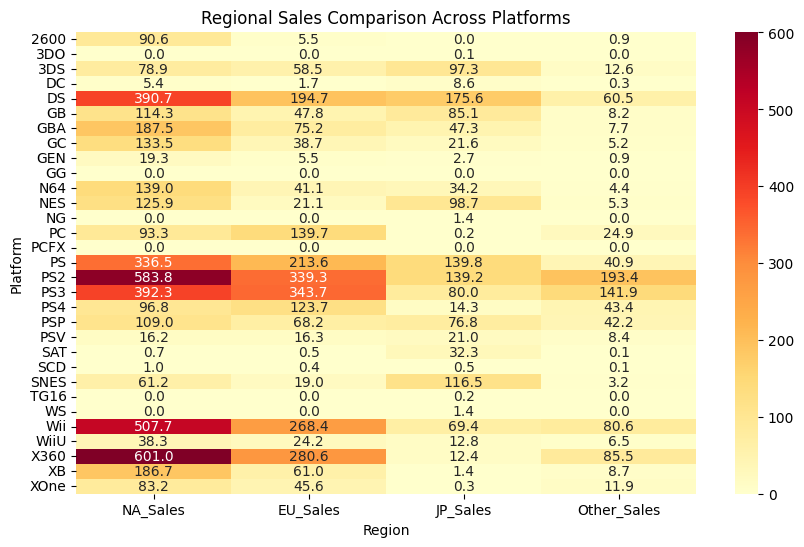

In [ ]:

platform_region_sales = df_1.groupby("Platform")[[
    "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"
]].sum()

plt.figure(figsize=(10, 6))
sns.heatmap(
    platform_region_sales,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Regional Sales Comparison Across Platforms")
plt.xlabel("Region")
plt.ylabel("Platform")
plt.show()


How has the market evolved by platform over time


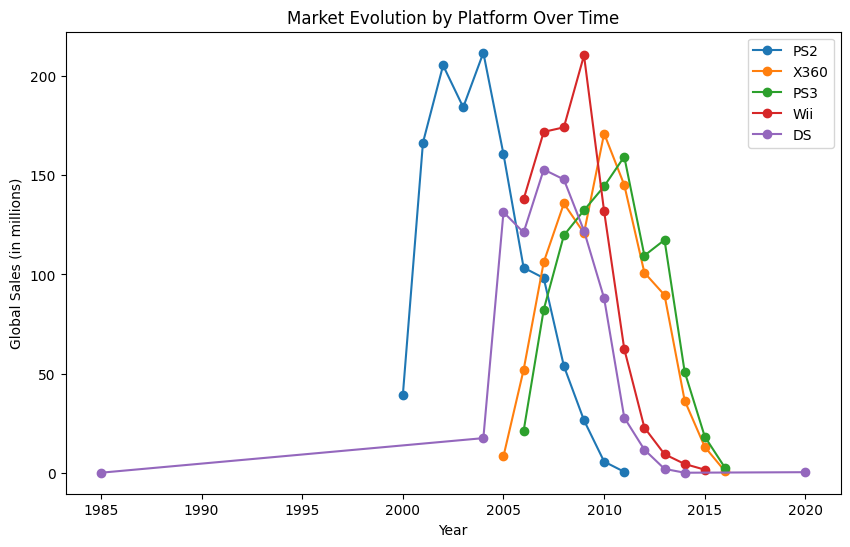

In [ ]:

platform_year_sales = df_1.groupby(
    ["Year", "Platform"]
)["Global_Sales"].sum().reset_index()
top_platforms = (platform_year_sales.groupby("Platform")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index

    )

plt.figure(figsize=(10, 6))

for platform in top_platforms:
    data = platform_year_sales[platform_year_sales["Platform"] == platform]
    plt.plot(
        data["Year"],
        data["Global_Sales"],
        marker="o",
        label=platform
    )

plt.xlabel("Year")
plt.ylabel("Global Sales (in millions)")
plt.title("Market Evolution by Platform Over Time")
plt.legend()
plt.show()


What are the regional genre preferences

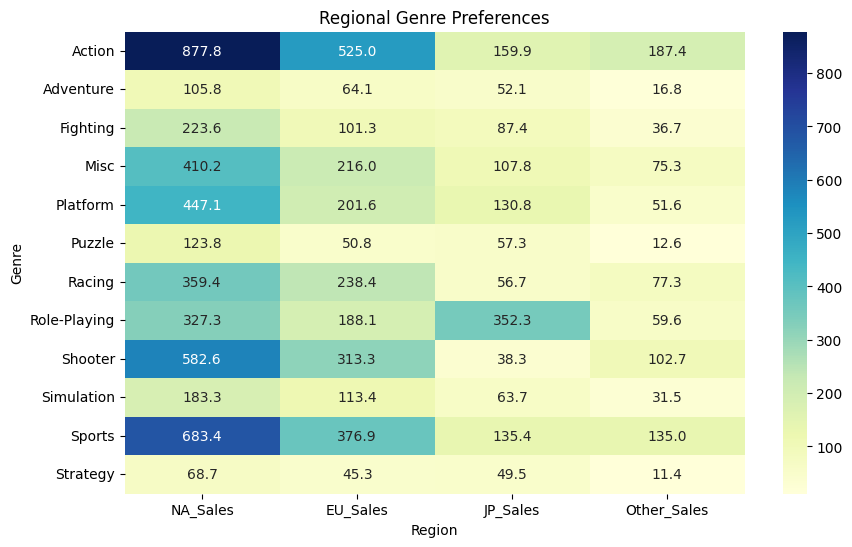

In [ ]:
genre_region_sales = df_1.groupby("Genre")[[
    "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"
]].sum()


plt.figure(figsize=(10, 6))
sns.heatmap(
    genre_region_sales,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Regional Genre Preferences")
plt.xlabel("Region")
plt.ylabel("Genre")
plt.show()


What’s the yearly sales change per region


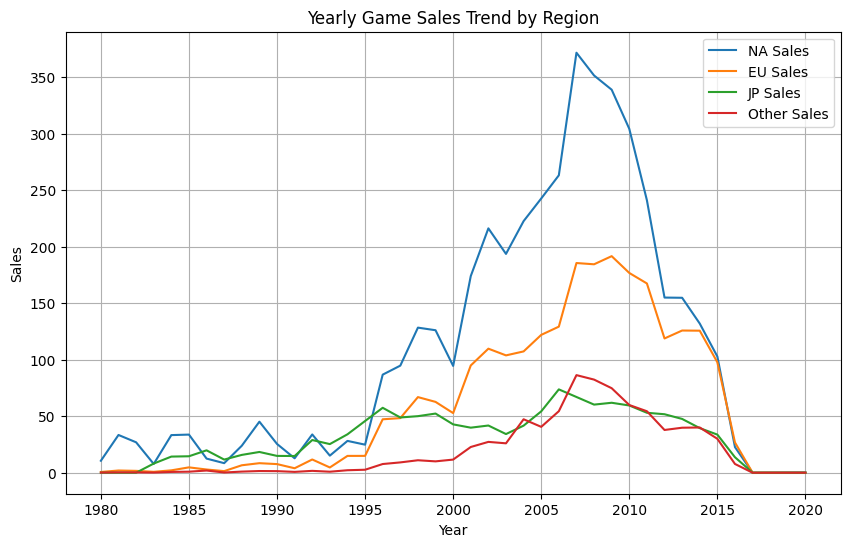

In [ ]:
yearly_region_sales = df_1.groupby("Year")[[
    "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"
]].sum()


plt.figure(figsize=(10, 6))

plt.plot(yearly_region_sales.index, yearly_region_sales["NA_Sales"], label="NA Sales")
plt.plot(yearly_region_sales.index, yearly_region_sales["EU_Sales"], label="EU Sales")
plt.plot(yearly_region_sales.index, yearly_region_sales["JP_Sales"], label="JP Sales")
plt.plot(yearly_region_sales.index, yearly_region_sales["Other_Sales"], label="Other Sales")

plt.xlabel("Year")
plt.ylabel("Sales")
plt.title("Yearly Game Sales Trend by Region")
plt.legend()
plt.grid(True)
plt.show()



Average sales per publisher

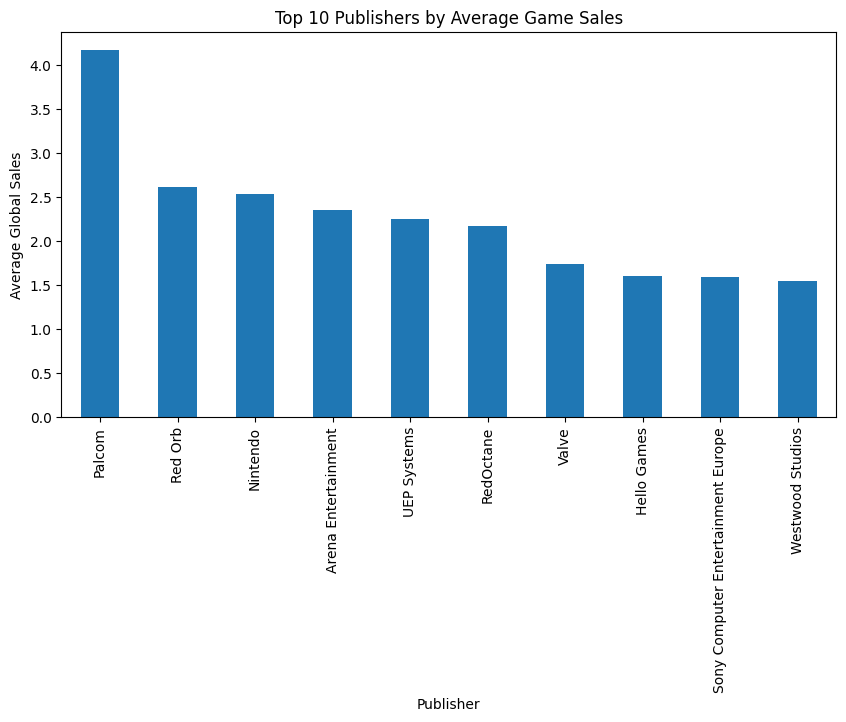

In [ ]:
avg_sales_per_publisher = df_1.groupby("Publisher")["Global_Sales"].mean()
avg_sales_per_publisher.sort_values(ascending=False).head(10).plot(kind="bar", figsize=(10,5))

plt.xlabel("Publisher")
plt.ylabel("Average Global Sales")
plt.title("Top 10 Publishers by Average Game Sales")
plt.show()


The top 5 best-selling games per platform

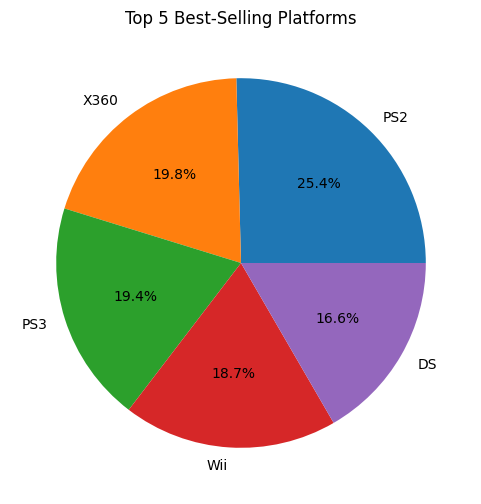

In [ ]:
platform_sales = df_1.groupby("Platform")["Global_Sales"].sum()
top5_platforms = platform_sales.sort_values(ascending=False).head(5)
top5_platforms.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Top 5 Best-Selling Platforms")
plt.ylabel("")
plt.show()



Rating affect global sales

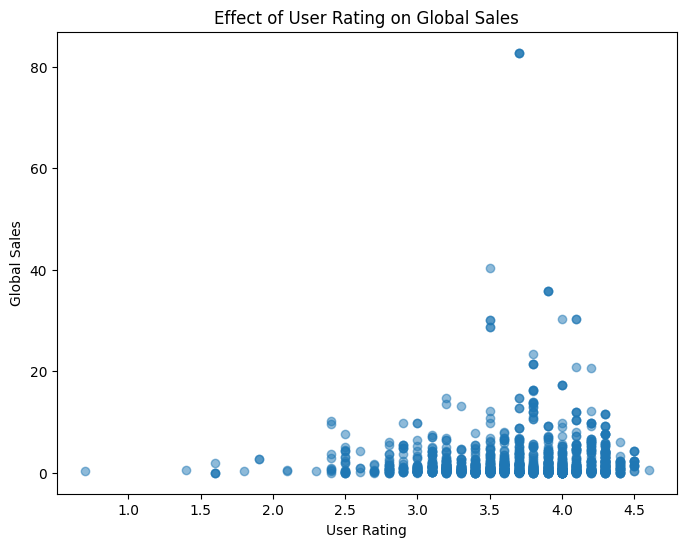

In [4]:

ratings_df = df[["Title", "Rating"]].copy()
sales_df   = df_1[["Name", "Global_Sales"]].copy()

ratings_df.rename(columns={"Title": "Game"}, inplace=True)
sales_df.rename(columns={"Name": "Game"}, inplace=True)

merged_df = pd.merge(
    ratings_df,
    sales_df,
    on="Game",
    how="inner"
)


plt.figure(figsize=(8,6))
plt.scatter(
    merged_df["Rating"],
    merged_df["Global_Sales"],
    alpha=0.5
)

plt.xlabel("User Rating")
plt.ylabel("Global Sales")
plt.title("Effect of User Rating on Global Sales")
plt.show()


platforms have the most games with high ratings (above 4)

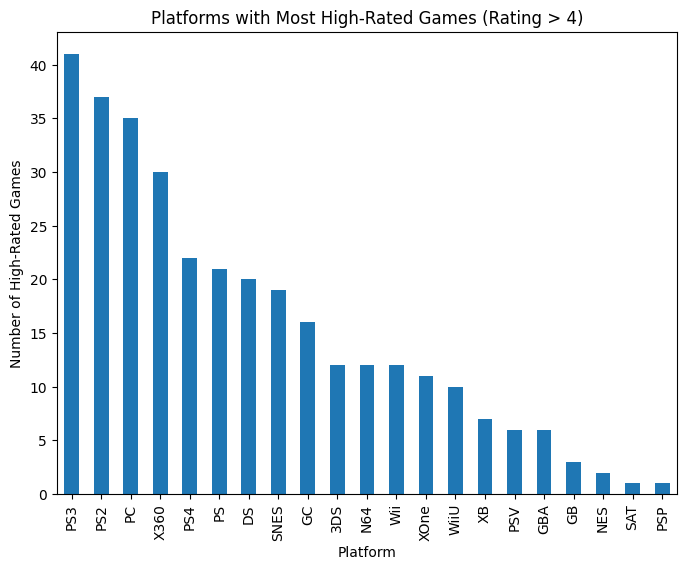

In [5]:

ratings_df = df[["Title", "Rating"]].copy()
platform_df = df_1[["Name", "Platform"]].copy()
ratings_df.rename(columns={"Title": "Game"}, inplace=True)
platform_df.rename(columns={"Name": "Game"}, inplace=True)
merged_df = pd.merge(
    ratings_df,
    platform_df,
    on="Game",
    how="inner"
)
high_rated_games = merged_df[merged_df["Rating"] > 4]
platform_counts = high_rated_games["Platform"].value_counts()
plt.figure(figsize=(8,6))
platform_counts.plot(kind="bar")
plt.xlabel("Platform")
plt.ylabel("Number of High-Rated Games")
plt.title("Platforms with Most High-Rated Games (Rating > 4)")
plt.show()


The trend of releases and sales over time


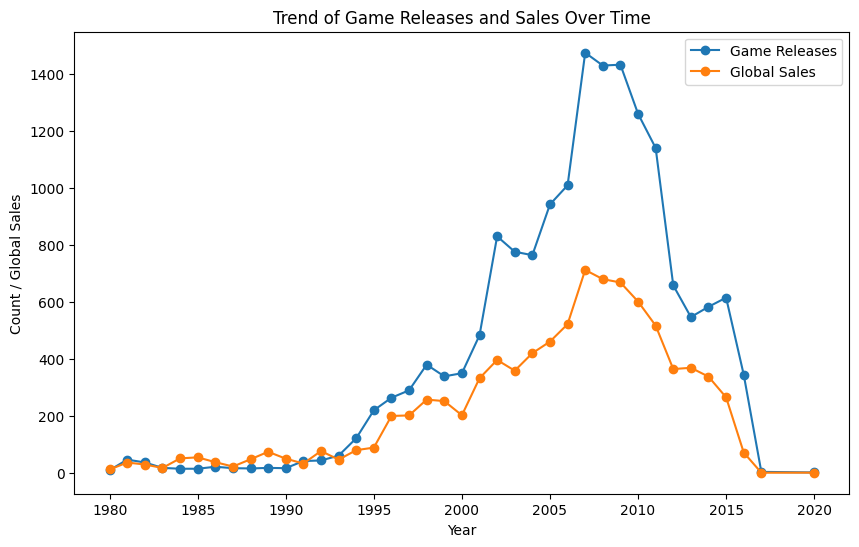

In [6]:

trend_df = df_1[["Year", "Global_Sales"]].copy()


release_trend = trend_df["Year"].value_counts().sort_index()

sales_trend = trend_df.groupby("Year")["Global_Sales"].sum()

plt.figure(figsize=(10,6))

plt.plot(
    release_trend.index,
    release_trend.values,
    label="Game Releases",
    marker="o"
)

plt.plot(
    sales_trend.index,
    sales_trend.values,
    label="Global Sales",
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Count / Global Sales")
plt.title("Trend of Game Releases and Sales Over Time")
plt.legend()
plt.show()


In [ ]:
Do highly wishlisted games lead to more sales


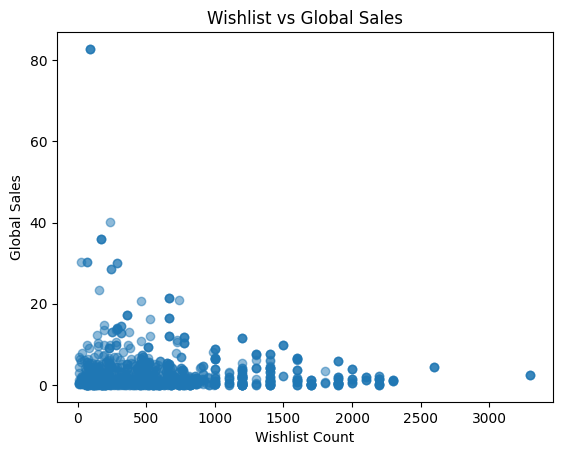

In [7]:
wishlist_df = df[["Title", "Wishlist"]].copy()
sales_df    = df_1[["Name", "Global_Sales"]].copy()

wishlist_df.rename(columns={"Title": "Game"}, inplace=True)
sales_df.rename(columns={"Name": "Game"}, inplace=True)

merged_df = pd.merge(
    wishlist_df,
    sales_df,
    on="Game",
    how="inner"
)

plt.scatter(
    merged_df["Wishlist"],
    merged_df["Global_Sales"],
    alpha=0.5
)

plt.xlabel("Wishlist Count")
plt.ylabel("Global Sales")
plt.title("Wishlist vs Global Sales")
plt.show()


Which genres have the highest engagement but lowest sales


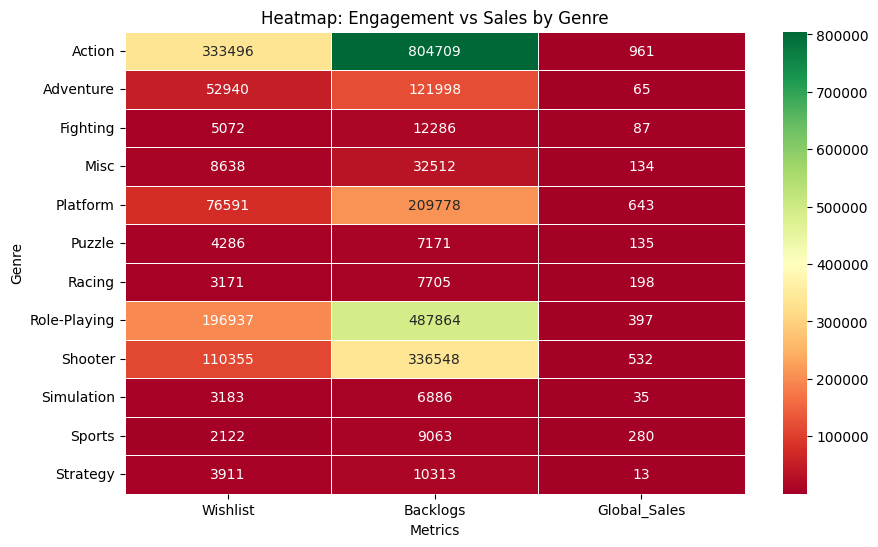

In [9]:

engagement_df = df[["Title", "Wishlist", "Backlogs"]].copy()
sales_df = df_1[["Name", "Genre", "Global_Sales"]].copy()


engagement_df.rename(columns={"Title": "Game"}, inplace=True)
sales_df.rename(columns={"Name": "Game"}, inplace=True)
merged_df = pd.merge(
    engagement_df,
    sales_df,
    on="Game",
    how="inner"
)
genre_summary = (
    merged_df
    .groupby("Genre")[["Wishlist", "Backlogs", "Global_Sales"]]
    .sum()
)


plt.figure(figsize=(10,6))
sns.heatmap(
    genre_summary,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Heatmap: Engagement vs Sales by Genre")
plt.xlabel("Metrics")
plt.ylabel("Genre")
plt.show()


In [ ]:
Do highly listed games (wishlist/backlogs) correlate with better ratings

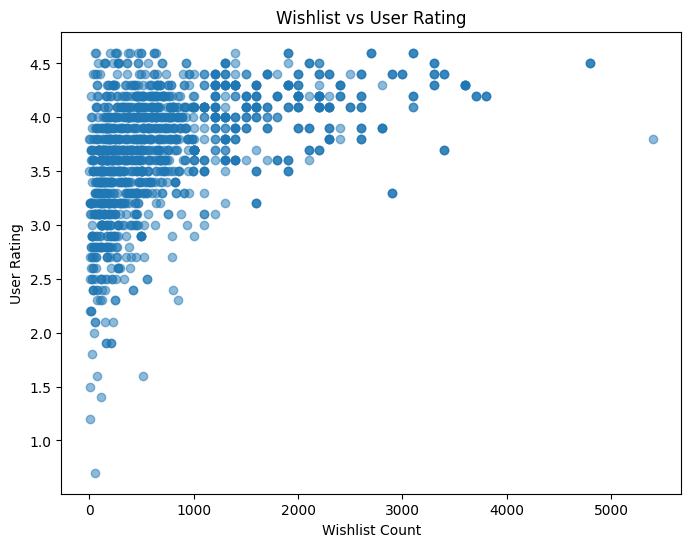

In [10]:

engagement_df = df[["Title", "Wishlist", "Rating"]].copy()
engagement_df.rename(columns={"Title": "Game"}, inplace=True)
plt.figure(figsize=(8,6))
plt.scatter(
    engagement_df["Wishlist"],
    engagement_df["Rating"],
    alpha=0.5
)

plt.xlabel("Wishlist Count")
plt.ylabel("User Rating")
plt.title("Wishlist vs User Rating")
plt.show()


In [ ]:
 How does user engagement differ across genres


<Figure size 1200x600 with 0 Axes>

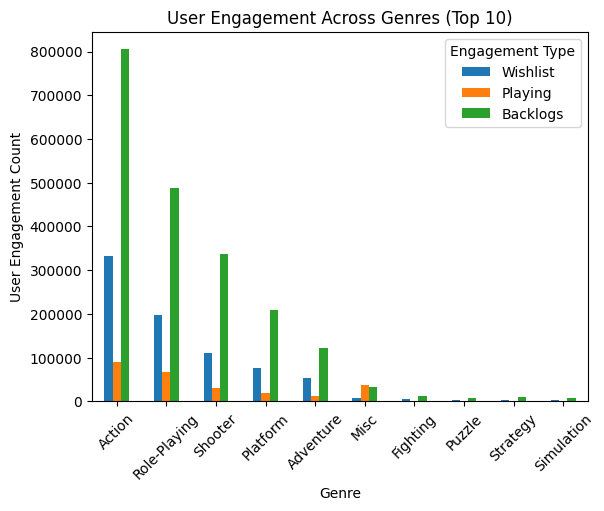

In [14]:

engagement_df = df[["Title", "Playing", "Wishlist", "Backlogs"]].copy()

genre_df = df_1[["Name", "Genre"]].copy()
engagement_df.rename(columns={"Title": "Game"}, inplace=True)
genre_df.rename(columns={"Name": "Game"}, inplace=True)
merged_df = pd.merge(
    engagement_df,
    genre_df,
    on="Game",
    how="inner"
)
genre_engagement = (
    merged_df
    .groupby("Genre")[["Wishlist", "Playing", "Backlogs"]]
    .sum()
    .sort_values(by="Wishlist", ascending=False)
)
top_genres = genre_engagement.head(10)
plt.figure(figsize=(12,6))
top_genres.plot(kind="bar")

plt.xlabel("Genre")
plt.ylabel("User Engagement Count")
plt.title("User Engagement Across Genres (Top 10)")
plt.xticks(rotation=45)
plt.legend(title="Engagement Type")
plt.show()


In [ ]:
Regional sales heatmap by genre reveal

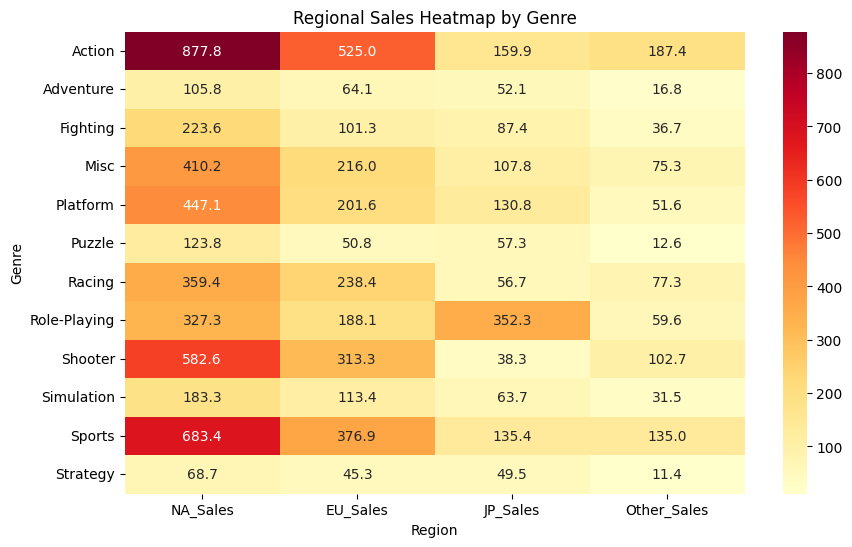

In [15]:

region_df = df_1[[
    "Genre",
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales"
]].copy()


genre_region_sales = (
    region_df
    .groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]]
    .sum()
)

plt.figure(figsize=(10,6))
sns.heatmap(
    genre_region_sales,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Regional Sales Heatmap by Genre")
plt.xlabel("Region")
plt.ylabel("Genre")
plt.show()
